## SC3021 Group 9's Project
### Tutorial Group: FDAG

#### Team Members:
#### 1) Phua Gu Guang
#### 2) Jayanth Sandalya Avadhanam Srihari
#### 3) Kogeshwaran Kalathran

# Problem Understanding



## Project background

Retail investors often struggle to recognise high volatility periods in the stock market, often leading to poor buy/sell decisions that could be better optimised. This project aims to develop a data science system that analyzes historical stock data to **quantify short-term volatility** and classify whether the stock is likely to enter high-volatiity period or not.

## Volatility

Stock market volatility is a crucial indicator of risk and uncertainty in financial markets. Sudden increase of volatility could indicate that the market is going through a period of instability and uncertainty.

In financial markets, volatility tend to come in clusters, meaning to say, periods of high volatility tend to be followed by even more high volatility periods.

This suggests that by using past historical data, we can use it to help analyse and predict the patterns of future changes in price. Data science methods can certainly aid in achieving such analysis and predictions.

In this project, the system integrates multiple data sources and applies statistical analysis and supervised learning to produce interpretable volatility risk indicators, rather than financial advice.





## 1) ASK
### **Can historical stock prices be used to predict near-term stock volatility?**

Specifically, this project aims to examine whether historial patterns in stock prices contain sufficient information to identify future periods of high volatility.

To assesss the effectiveness of our hypothesis, we have selected three stocks that represent different volatility regimes. One relatively stable stock, one highly volatile stock and one neutral stock that represents market behaviour in the long run. With these three datasets, we are better able to compare these data and do a thorough evaluation of the prediction anaylsis across the three different types of stocks.



### Requirement Analysis:
To meet the project goal of volatility analysis, we first have to select time-aligned historical market data that lets us obtain the closing stock prices and calculate the logarithmic returns and from it, its respective rolling volatility. The data required should be at daily granularity, capturing the trading activity per day excluding weekends and public holidays. In addition, we also require risk indicators as well as other macroeconomic factors to better compute a more accurate analysis. Specifically, we incorporated the VIX index as a market-wide risk indicator, the 10-Year US Treasury Yield as a reflection of interest rates expectation. Each of these macroeconomic indicators plays a crucial role in allowing us to better predict periods of higher volatility.

<br>

List of considered data sources:
- Historical stock prices of selected stocks (AAPL, TSLA, JNJ) from Yahoo Finance
- Trading volume of selected stocks from Yahoo Finance
- VIX index obtained from Federal Reserve Economic Data (FRED)
- 10-Year US Treasury Yield from Kaggle
- Earnings Surprise Data from Alpha Vantage

## 2) PREPARE
## Dataset #1 - Historical Stock Prices

#### Data Included
- Daily open, close, adjusted close prices
- Trading volume

This dataset provides the core signal for the system. It is used to
- Compute log returns
- Quantify short-term volatility using rolling windows
- Define the binary target variable

Link of data sources from Yahoo Finance:
1) AAPL https://sg.finance.yahoo.com/quote/AAPL/history/?period1=1609459200&period2=1767139200

2) JNJ https://sg.finance.yahoo.com/quote/JNJ/history/?period1=1609459200&period2=1767139200

3) TSLA https://sg.finance.yahoo.com/quote/TSLA/history/?period1=1609459200&period2=1767139200


Data source steps
1. Create historical stock price CSV with yfinance API call.
2. Clean data in CSV by removing null columns, public holidays and weekends.
3. Import data to relational database.

The reason why our team has selected Yahoo Finance as the primary data source is because it provides reliable, publicly available historical stock price data suitable for volatility analysis which is perfect for our project. The dataset spans from 2021 to 2025 which provides us with a comprehensive and sufficient historical coverage to capture different market conditions which includes non-volatile and volatile periods.

The data obtained spans from 2021 to 2025, providing sufficient historical coverage to back up our predictive analysis. In addition, the data encapsulates the various market conditions across the years, ranging from periods of stability and periods of high movements. This time range will allow the model to learn the patterns and provide us with a more accurate analysis.

For data cleaning process, we have ensured that the data we have exclude any non-trading days such as weekends and public holidays. The raw-data will then be transformed to one of high-quality that is ready-to-use. This is to ensure data quality and consistency. The cleaned datasets are then stored in a CSV file to allow us for a better analysis.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


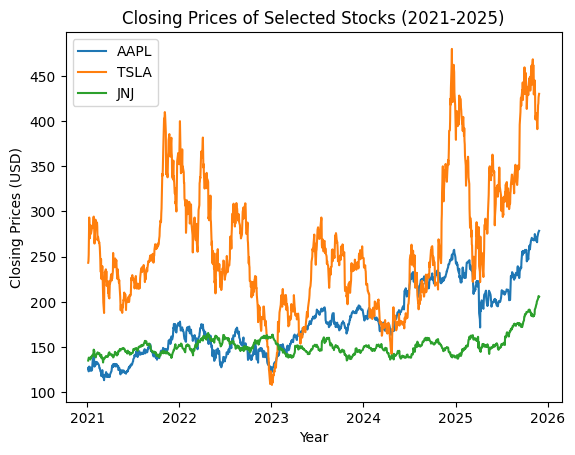

In [17]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

aapl = yf.download("AAPL", start="2021-01-01", end="2025-12-01")
tsla = yf.download("TSLA", start="2021-01-01", end="2025-12-01")
jnj  = yf.download("JNJ",  start="2021-01-01", end="2025-12-01")

plt.figure()
plt.plot(aapl.index, aapl['Close'], label='AAPL')
plt.plot(tsla.index, tsla['Close'], label='TSLA')
plt.plot(jnj.index,  jnj['Close'],  label='JNJ')
plt.xlabel("Year")
plt.ylabel("Closing Prices (USD)")
plt.title("Closing Prices of Selected Stocks (2021-2025)")
plt.legend()
plt.show()



From above, we can observe that TSLA exhibits larger and more frequent price changes compared to AAPL and JNJ, suggesting greater variability in its price movements. AAPL displayed relatively smoother prices changes while JNJ representing a more stable price behaviour. These stark differences allows us to visualise the extend of price variability in the respective stocks. The diversity in price behaviour across the three selected stocks ensures that our model is trained on various market conditions, improving its ability to generate a more accurate analysis.

However, base on this source: https://365financialanalyst.com/knowledge-hub/corporate-finance/log-return/

Therefore, stock prices alone cannot be used to derive the volatility of itself using only its historical data. As such, we also had to use logarithmic (log) returns to aid in this study. We first have to convert the daily closing prices into log returns and from there, we can then use the standard deviation to measure the rolling volatility of the stock.








For consecutive trading days $t$ and $t-1$, we define the log return as:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

where $P_t$ denotes the closing price of the stock on day $t$.


After we have calculated the $r_t$ of the stock daily, we then use it to calculate the rolling volatility ($\sigma_t$) by taking the standard deviation of the $r_t$ from trading day 1 to trading day 19. The reason for 20 days is because the US market has about 250 trading days which averages to about 20 days per month.

The formula for calculating rolling volatility is as such:

$$
\sigma_t
= \sqrt{\frac{1}{n-1}\sum_{i=0}^{n-1}
\left(r_{t-i} - \bar{r}\right)^2}
$$


where $r_t$ denotes the log return, $\bar{r}$ denotes the mean value of the log returns and $n$ denotes the number of days which is 20 as mentioned above.

This will then return the rolling volatility of one month and we will continue this process for five years and then take this value and plot the stock against one another as shown below.


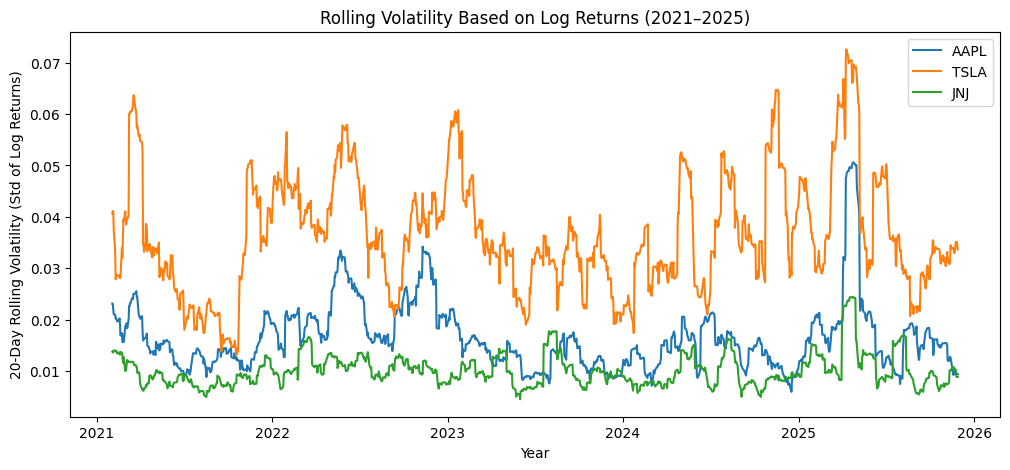

In [18]:
start_date = "2021-01-01"
end_date   = "2025-12-01"
tickers    = ["AAPL", "TSLA", "JNJ"]
existing_dataframe = pd.concat([aapl,tsla,jnj])


data = existing_dataframe

price = data["Adj Close"].copy() if "Adj Close" in data.columns else data["Close"].copy()

price = price.dropna(how="all")

log_returns = np.log(price / price.shift(1))

window = 20

volatility = log_returns.rolling(window=window, min_periods=window).std()

plt.figure(figsize=(12, 5))
for t in tickers:
    plt.plot(volatility.index, volatility[t], label=t)

plt.xlabel("Year")
plt.ylabel(f"{window}-Day Rolling Volatility (Std of Log Returns)")
plt.title("Rolling Volatility Based on Log Returns (2021–2025)")
plt.legend()
plt.show()


The rolling volatility plot derived from log returns highlights distinct and consistent differences in volatility behaviour across the three stocks. From above, we can observe that TSLA consistently exhibits the highest volatility with often and sharp spikes, indicating a highly volatile regime. JNJ maintains comparatively low and stable volatility throughout the period, while AAPL displays moderate volatility levels.

In addition, volatility appears to cluster over time, with periods high volatility followed by periods of stability. This behaviour is a well-documented phenomenon in financial markets and it suggests that volatility is not entirely random. W can then use this information to our advantage, making it more feasible to conduct a predictive analysis based on the evidence we have garnered.

### Dataset #1 Profilling - Closing Stock Prices (AAPL, TSLA, JNJ)

To assess the suitability of the stock price dataset for our analysis,
we perform a series of data profiling steps, which includes single-column and multi-column. This includes examining the
shape of the dataset, checking for null values, verifying the date range,
reviewing descriptive statistics, and identifying any anomalies such as
duplicate entries, zero volume days or closing prices outside of daily ranges. These steps allow us to better
understand the quality and completeness of the data before proceeding
to the processing stage.


In [19]:
print("=" * 60)
print("DATASET #1 — STOCK PRICES (AAPL, TSLA, JNJ)")
print("=" * 60)

for name, stock in [("AAPL", aapl), ("TSLA", tsla), ("JNJ", jnj)]:
    print(f"\n--- {name} ---")

    # 1. Shape
    print(f"\n[1] Shape: {stock.shape[0]} rows x {stock.shape[1]} columns")

    # 2. Data Types
    print(f"\n[2] Data Types:\n{stock.dtypes}")

    # 3. Null Value Check
    null_counts = stock.isnull().sum()
    null_pct = (null_counts / len(stock)) * 100
    print(f"\n[3] Null Value Check:")
    print(pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct}))

    # 4. Date Range
    print(f"\n[4] Date Range:")
    print(f"    Start              : {stock.index.min().date()}")
    print(f"    End                : {stock.index.max().date()}")
    print(f"    Total Trading Days : {len(stock)}")

    # 5. Descriptive Statistics
    print(f"\n[5] Descriptive Statistics:\n{stock.describe()}")

    # 6. Duplicate Check
    print(f"\n[6] Duplicate Rows  : {stock.duplicated().sum()}")
    print(f"    Duplicate Dates : {stock.index.duplicated().sum()}")

    # 7. Zero/Negative Close Prices
    close_col = stock['Close']
    print(f"\n[7] Zero/Negative Close Prices: {(close_col <= 0).sum()}")

    # 8. Volume Anomalies
    print(f"\n[8] Days with Zero Volume: {(stock['Volume'] == 0).sum()}")

    # 9. Multi-Column Dependency Check (Low <= Close <= High)
    invalid = ((stock['Close'] < stock['Low']) |
               (stock['Close'] > stock['High'])).sum()
    print(f"\n[9] Dependency Check (Close outside Low-High range): {invalid}")

    print("\n" + "-" * 60)

DATASET #1 — STOCK PRICES (AAPL, TSLA, JNJ)

--- AAPL ---

[1] Shape: 1233 rows x 5 columns

[2] Data Types:
Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

[3] Null Value Check:
               Null Count  Null %
Price  Ticker                    
Close  AAPL             0     0.0
High   AAPL             0     0.0
Low    AAPL             0     0.0
Open   AAPL             0     0.0
Volume AAPL             0     0.0

[4] Date Range:
    Start              : 2021-01-04
    End                : 2025-11-28
    Total Trading Days : 1233

[5] Descriptive Statistics:
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1233.000000  1233.000000  1233.000000  1233.000000  1.233000e+03
mean     177.648481   179.409271   175.708945   177.461863  7.031137e+07
std       38.247372    38.47550

From above, we can first split the results into three main categories:
 - Null values and profilling completeness
 - Profilling price distribution
 - Multi-column dependency check

<br>

1\) Null values and profilling completeness

The null values check allows us to sieve out any null values present in the stock prices. The output has revealed that none of the attributes across all three stocks contain any null values, indicating that the dataset is complete and well-maintained. This confirms that the data obatined from yfinance is of high-quality and requires minimal data cleaning.

<br>

2\) Profiling price distribution

The distribution allows us to observe that the price variability amongst the three stocks are very distinct. This is perfomed by using a single-column profilng technique data profilling type called cardinality. For AAPL, the average closing price was at \$177.65 with a standard deviation of $38.25. For TSLA, the average closing price was at \$262.07 with a standard deviation of \$73.19. Lastly, for JNJ, its average closing price is at \$151.31 with a standard deviation of \$10.97. From these values, we can confirm that TSLA has a highly volatile price distribution and on the other hand, JNJ has the most consistent closing stock price.

<br>

3\) Multi-column dependency check

To check whether the data has any errors, we have to check whether the closing stock price falls within the range of its daily low and high price range to ensure that the data obtained is legitamate. A violation of such would indicate a data error. It is then shown that there are no such violations across all three stocks, signalling that the sources are entirely valid and clean.

<br>

Data Quality Evaluation

Finally, the data quality of DS1 is well-suited for this project analysis as it provides a very comprehensive coverage of the closing stock prices. The completeness and consistent date coverage is ideal for our predictive analysis and it is perfect for us to perform mathematical calculation like logarithmic returns and rolling volatiliy as shown above.



## Dataset #2 - Liquidity & Trading Activity

Data Included:
- Daily trading volume (independent feed)
- Derived liquidity metrics (rolling average volume, volume % change)

Role:
This dataset captures liquidity conditions, which are a key driver of volatility
- Identify abnormal trading pressure
- Explain volatility spikes beyond price movements
- Improve model interpretability and diagnostic analysis

Liquidity shocks often amplify short-term volatility. Incorporating this data allows the system to move beyond purely historical price patterns and provides a causal explanation for emerging risk.


Volume ratio is to be computed here to compare today's volume to recent average volume. The interpretation is as such:

If ratio > 1, abnormal trading intensity

If ratio ≈ 1, normal liquidity conditions.

In [20]:
import yfinance as yf
import pandas as pd

# --- config ---
ticker = {
    "AAPL": aapl,
    "TSLA": tsla,
    "JNJ": jnj
}

for symbol, df in ticker.items():

    # reset index
    df = df.reset_index().rename(columns={"Date": "date"}).sort_values("date")

    volume = df["Volume"]

    # if Volume is accidentally a DataFrame, flatten it
    if isinstance(volume, pd.DataFrame):
        volume = volume.iloc[:, 0]

    # Liquidity feature engineering
    df["volume_pct_change"] = volume.pct_change()
    df["avg_volume_20d"] = volume.rolling(20).mean()  # changed to 20d
    df["volume_ratio"] = volume / df["avg_volume_20d"]

    # Final liquidity dataset
    liquidity_df = df[[
        "date",
        "Volume",
        "volume_pct_change",
        "avg_volume_20d",
        "volume_ratio"
    ]].copy()

    liquidity_df = liquidity_df.dropna()  # drop first 19 NaN rows

    print(liquidity_df.round(3).head(10))
    liquidity_df.to_csv(f"{symbol}_liquidity_yfinance.csv", index=False)

Price        date     Volume volume_pct_change avg_volume_20d volume_ratio
Ticker                  AAPL                                              
19     2021-02-01  106239800            -0.402    117325090.0        0.906
20     2021-02-02   83305400            -0.216    114325265.0        0.729
21     2021-02-03   89880900             0.079    113936065.0        0.789
22     2021-02-04   84183100            -0.063    110390820.0        0.763
23     2021-02-05   75693800            -0.101    108696600.0        0.696
24     2021-02-08   71297200            -0.058    107003550.0        0.666
25     2021-02-09   76774200             0.077    105823035.0        0.725
26     2021-02-10   73046600            -0.049    104877810.0        0.696
27     2021-02-11   64280000            -0.120    103659970.0        0.620
28     2021-02-12   60145100            -0.064    102156135.0        0.589
Price        date     Volume volume_pct_change avg_volume_20d volume_ratio
Ticker                  T

### Dataset #2 Profiling - Liquidity and Trading Activity (AAPL, TSLA, JNJ)

To assess the suitability of the trading volume data of our analysis, we must perfrom several profilling steps focusing on the volume attributes across all three selected stocks. This mainly includes identifying whether they are any zero or negative volume days. Furthermore, a multi-column dependency check is also performed to validate the movement between volume and price movement.



In [21]:
print("=" * 60)
print("DATASET #2 — TRADING VOLUME (AAPL, TSLA, JNJ)")
print("=" * 60)

for name, stock in [("AAPL", aapl), ("TSLA", tsla), ("JNJ", jnj)]:
    print(f"\n--- {name} ---")

    # 1. Shape
    vol = stock[['Volume']].copy()
    print(f"\n[1] Shape: {vol.shape[0]} rows x {vol.shape[1]} column")

    # 2. Data Types
    print(f"\n[2] Data Types:\n{vol.dtypes}")

    # 3. Null Value Check
    null_counts = vol.isnull().sum()
    null_pct = (null_counts / len(vol)) * 100
    print(f"\n[3] Null Value Check:")
    print(pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct}))

    # 4. Date Range
    print(f"\n[4] Date Range:")
    print(f"    Start              : {vol.index.min().date()}")
    print(f"    End                : {vol.index.max().date()}")
    print(f"    Total Trading Days : {len(vol)}")

    # 5. Descriptive Statistics
    print(f"\n[5] Descriptive Statistics:\n{vol.describe()}")

    # 6. Duplicate Check
    print(f"\n[6] Duplicate Rows  : {vol.duplicated().sum()}")
    print(f"    Duplicate Dates : {vol.index.duplicated().sum()}")

    # 7. Zero or Negative Volume Days
    print(f"\n[7] Zero Volume Days    : {(vol['Volume'] == 0).sum()}")
    print(f"    Negative Volume Days: {(vol['Volume'] < 0).sum()}")

    # 8. Volume Outlier Detection (Volume Ratio > 1)
    vol_values = stock['Volume'].values.flatten()
    avg_volume = vol_values.mean()
    volume_ratio = vol_values / avg_volume
    abnormal_days = (volume_ratio > 1).sum()
    print(f"\n[8] Abnormal Volume Days (Volume Ratio > 1): {abnormal_days} days "
          f"({abnormal_days/len(stock)*100:.1f}% of total)")

    # 9. Multi-Column Dependency Check
    # High volume days should correspond to larger price movements
    stock['price_change'] = abs(stock['Close'].values.flatten() - stock['Open'].values.flatten())
    correlation = pd.Series(stock['Volume'].values.flatten()).corr(pd.Series(stock['price_change'].values.flatten()))
    print(f"\n[9] Dependency Check (Volume vs Price Movement Correlation): "
          f"{correlation:.4f}")

    print("\n" + "-" * 60)

DATASET #2 — TRADING VOLUME (AAPL, TSLA, JNJ)

--- AAPL ---

[1] Shape: 1233 rows x 1 column

[2] Data Types:
Price   Ticker
Volume  AAPL      int64
dtype: object

[3] Null Value Check:
               Null Count  Null %
Price  Ticker                    
Volume AAPL             0     0.0

[4] Date Range:
    Start              : 2021-01-04
    End                : 2025-11-28
    Total Trading Days : 1233

[5] Descriptive Statistics:
Price         Volume
Ticker          AAPL
count   1.233000e+03
mean    7.031137e+07
std     2.981471e+07
min     2.013560e+07
25%     4.874940e+07
50%     6.380400e+07
75%     8.492240e+07
max     3.186799e+08

[6] Duplicate Rows  : 2
    Duplicate Dates : 0

[7] Zero Volume Days    : Ticker
AAPL    0
dtype: int64
    Negative Volume Days: Ticker
AAPL    0
dtype: int64

[8] Abnormal Volume Days (Volume Ratio > 1): 504 days (40.9% of total)

[9] Dependency Check (Volume vs Price Movement Correlation): 0.3389

--------------------------------------------------

From above, we can also perform similar results analysis as DS1 and split it into three main categories.
- Null values and dataset completeness
- Volume distribution
- Multi-column dependency check

<br>

1\) Null values and dataset completeness

The null values check allows us to minimise any data errors and sieve out any null values present in the trading volume data. The output of the code has then revealed that are no null values, zero volume days and negative volume days, indicating that the dataset is complete and has no errors. However, there were duplicate rows in AAPL (2) and JNJ (7). This will then be cleaned in the later stage of data cleaning. This showcases the importance of a thorough data profilling to ensure data integrity and minimise any chances of errors.

Upon further investigation, no duplicate dates were detected. Meaning to say, the duplicate entries for AAPL and JNJ are entirely coincidental as it represents data value for different dates. As such, these values will not be dropped and there is no need for us to do data cleaning.

<br>

2\) Volume distribution

The volume distributuon utilises a single-column profiling technique (Cardinality) to observe the trading volume of the respective stocks. TSLA recorded the highest average daily volumne of approximately 100.2 million shares, followed by AAPL with 70.3 million shares and lastly with JNJ at a much lower 8.3 million shares. The standard deviation of the stocks also follows a similar ranking at TSLA first with 39,3 million shares, then followed by AAPL with 29.8 million shares and then JNJ with 7.9 million shares. From these values, we can observe that TSLA has the highest trading activity amongst the three, reflecting the different levels of variability.

In addition, abnormal volume days were identified using the Relative Volume (RVOL) metric, where it takes the volume traded at that particular day divided by the 20-day rolling aevrage volume. As mentioned above, a volume ratio greater than 1 indicates an abnormal trading intensity. From the output, AAPL recorded 504 abnormal volume days which is 40.2% of total trading days. TSLA recorded 518 abnormal trading days (42.0%) and JNJ recordrd the least with 365 days (29.6%). The higher proportion of abnormal trading days observed in AAPL and TSLA is consistent with its higher sensitivity reflected from the closing stock prices while JNJ consistently remains the lowest with due to its relative stable nature.

<br>

3\) Multi-column dependency check

We also computed the correlation between daily volume and absolute price change for each respective stock. A higher correlation suggests that higher volume could coincide with larger price swings, supporting the analysis that we are trying to achieve. From the output, we observe that AAPL has a correlation of 0.3389, 0.2684 for TSLA and 0.1412 for JNJ. These values confirm that there is a positive relationship between volume and price movements.

<br>

Data Quality Evaluation

The data quality of DS2 is largely acceptable and well-suited for this project as it manages to capture the meaning and relationship betweeen volume and price change. The positive volume-price correlation serves as a important tool for us and it crucial in providing insights into our predictive analysis. It will be addressed in the later stage of data cleaning which will be subsequently used for prototype modelling. All in all, DS2 serves as a suitable complement to DS1 in providing valuable insights into this project.

## Dataset #3 - Market-Wide Volatility (VIX)

Data Included:
- Daily VIX index values (expected 30-day market volatility)
- Derived market risk metrics (VIX change, rolling VIX average)

Role: This dataset caputres systematic market risk, providing ontext for stock-level volatility
- Identify periods of market-wide stress
- Distinguish systematic volatility from stock specific risk
- Reduce false risk signals during broad market turbulence

Market-wide uncertainty can elevate volatility across many stocks simultaneously. Incorporating the VIX allows the system to contextualize individual stock volatility and avoid misclassifying general market stress as firm-specific risk.

Generally, a VIX level of <20 suggests normal and calm market conditions, 20-30 indicates elevated fear and volatility, >30 suggests high fear and significant market stress and anything >40 suggests extreme levels of panic and uncertainty which is commonly observed in major financial crisis.

In [22]:
import pandas_datareader.data as web

start = "2021-01-01"
end = "2025-12-01"

vix = web.DataReader("VIXCLS", "fred", start, end)
vix = vix.reset_index().rename(columns={
    "DATE": "date",
    "VIXCLS": "vix"
})

vix = vix.sort_values("date")


In [23]:
vix.head(10)

,date,vix
0,2021-01-01,NaN
1,2021-01-04,26.97
2,2021-01-05,25.34
3,2021-01-06,25.07
4,2021-01-07,22.37
5,2021-01-08,21.56
6,2021-01-11,24.08
7,2021-01-12,23.33
8,2021-01-13,22.21
9,2021-01-14,23.25


In [24]:
vix["vix_change"] = vix["vix"].diff()
vix["vix_5d_avg"] = vix["vix"].rolling(20).mean()
vix["high_market_risk"] = (vix["vix"] > 20).astype(int)

vix_clean = vix.dropna()

vix_clean.to_csv("vix_fred.csv", index=False)

### Dataset #3 Profiling - VIX Market Index

To assess the suitability of DS3, we must first perfrom a series of data profilling steps to check for any null values, imcompatible data values and for any anomalies such as extreme VIX spikes which may aid us in our analysis later on.

In [25]:
print("=" * 60)
print("DATASET #3 — VIX INDEX (FRED)")
print("=" * 60)

# 1. Shape
print(f"\n[1] Shape: {vix_clean.shape[0]} rows x {vix_clean.shape[1]} columns")

# 2. Data Types
print(f"\n[2] Data Types:\n{vix_clean.dtypes}")

# 3. Null Value Check
null_counts = vix_clean.isnull().sum()
null_pct = (null_counts / len(vix_clean)) * 100
print(f"\n[3] Null Value Check:")
print(pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct}))

# 4. Date Range
print(f"\n[4] Date Range:")
print(f"    Start              : {vix_clean['date'].min()}")
print(f"    End                : {vix_clean['date'].max()}")
print(f"    Total Trading Days : {vix_clean['date'].nunique()}")

# 5. Descriptive Statistics
print(f"\n[5] Descriptive Statistics:\n{vix_clean.describe()}")

# 6. Duplicate Check
print(f"\n[6] Duplicate Rows  : {vix_clean.duplicated().sum()}")
print(f"    Duplicate Dates : {vix_clean['date'].duplicated().sum()}")

# 7. Extreme VIX Spikes (VIX > 40)
extreme_vix = vix_clean[vix_clean['vix'] > 40]
print(f"\n[7] Extreme VIX Spikes (VIX > 40): {len(extreme_vix)} days")
if len(extreme_vix) > 0:
    print(extreme_vix)

# 8. High Market Risk Days (VIX > 20)
high_risk = vix_clean[vix_clean['vix'] > 20]
print(f"\n[8] High Market Risk Days (VIX > 20): {len(high_risk)} days "
      f"({len(high_risk)/len(vix_clean)*100:.1f}% of total)")

# 9. Multi-Column Dependency Check
invalid = (vix_clean['vix_change'] != vix_clean['vix'].diff()).sum()
print(f"\n[9] Dependency Check (vix_change consistency): {invalid} violations")

print("\n" + "-" * 60)

DATASET #3 — VIX INDEX (FRED)

[1] Shape: 920 rows x 5 columns

[2] Data Types:
date                datetime64[ns]
vix                        float64
vix_change                 float64
vix_5d_avg                 float64
high_market_risk             int64
dtype: object

[3] Null Value Check:
                  Null Count  Null %
date                       0     0.0
vix                        0     0.0
vix_change                 0     0.0
vix_5d_avg                 0     0.0
high_market_risk           0     0.0

[4] Date Range:
    Start              : 2021-03-15 00:00:00
    End                : 2025-12-01 00:00:00
    Total Trading Days : 920

[5] Descriptive Statistics:
                                date         vix  vix_change  vix_5d_avg  \
count                            920  920.000000  920.000000  920.000000   
mean   2023-10-19 22:16:41.739130368   18.809620   -0.018891   18.950521   
min              2021-03-15 00:00:00   11.860000  -18.710000   12.500500   
25%              

From above, we can apply the same result analysis from DS1 and DS2 and categorise them into 3 main components.
- Null values and dataset completness
- VIX distribution
<br>

1\) Null values and dataset completeness

The null value check helps to sieve out null values present in date,vix, vix_change and vix_5d_avg and high market risk to which all of the attributes contain zero null values. This confirms that the dataset is complete. Futhermore, there are no duplicate dates, meaning that each trading day is represented once, signalling a clean dataset.

<br>

2\) VIX distribution

The single-column profiling technique reveal that VIX index ranged from a minumun of 11.86 to a maximum of 52.33 over the dataset period of March 2021 to December 2025. The mean score is at 18.81 which is slightly below the acceptable level of 20. There are a total of 297 days out of 920 trading days (32.3%) that were above the level of 20 which is considered as high market risk, indicated by the `high_market_risk` flag.

Extreme VIX spikes (>40) was detected on 4 days. All of which occured between 4 April 2025 to 10 April 2025, with the highest recorded value of 52.33 on 8 April 2025. This could be due to the Liberation Day tariffs announcement made by President Donald Trump which caused a market-wide panic. Such extreme values are critical as it represents and reflects the exact type of volatility that we expect which is needed in our prototype modelling.

<br>

Data Quality Evaluation

Overall, the VIX dataset sourced from FRED is suitable for this project. Its completeness, minimal value errors and total coverage of market conditions makes it a strong risk indicator for prediction model, making it perfect complement to DS1 and DS2.






## Dataset #4 - 10-Year US Treasury Yield

Link to data source from Kaggle:

https://www.kaggle.com/datasets/eswaranmuthu/u-s-economic-vital-signs-25-years-of-macro-data?resource=download

Data included:
- Monthly 10-Year US Treasury Yield

Role:
This dataset provides the macroeconomic interest rate context for the volatility model. It helps to:
- Capture the effect of rising and falling interest rates on volatility
- Provides a reflection of the investors' assessment and confidence of the economy

The 10-Year US Treasury Yield is one of the most widely used macroeconomic indicators in the world. It measures the return on US government bonds held for 10 years. In the event of increased yields, it translates to an increased interest rate. As such, the cost of borrowing for corporations become more expensive, in turn reducing the level of future earnings potential which may then cause investors to sell, leading to higher volatility. Conversly, when yields fall, cost of borrowing becomes cheaper, corporate earnings expectations improve and markets tend to stabilise, resulting in periods of lower volatility.

Using Colab cache for faster access to the 'u-s-economic-vital-signs-25-years-of-macro-data' dataset.


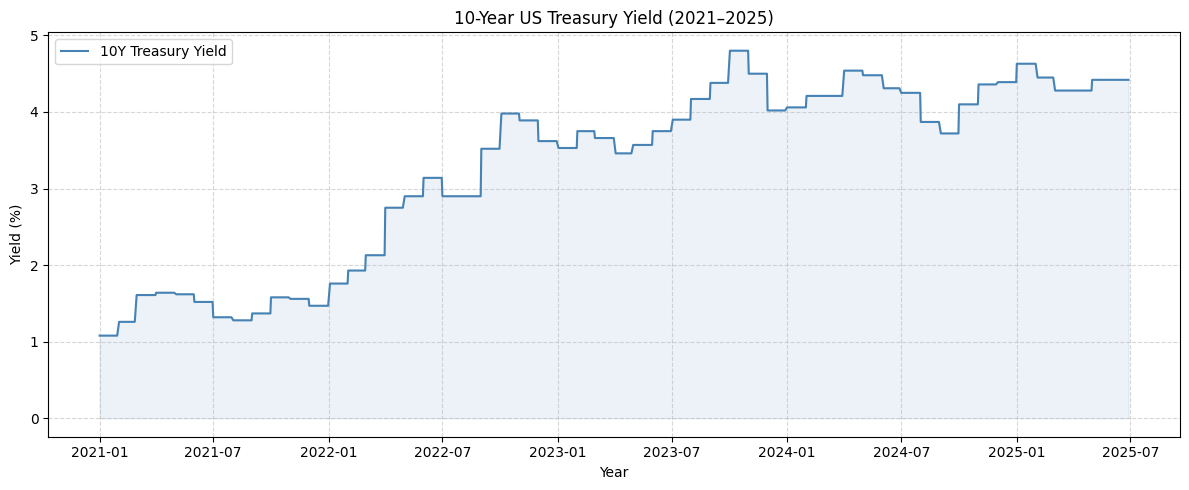

In [11]:
import warnings
warnings.filterwarnings('ignore')

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "eswaranmuthu/u-s-economic-vital-signs-25-years-of-macro-data",
  "macro_data_25yrs.csv",
)

# Extract 10Y Treasury Yield
treasury = df[['Date', '10Y Treasury Yield']].copy()
treasury = treasury.rename(columns={'10Y Treasury Yield': 'treasury_10y'})
treasury['Date'] = pd.to_datetime(treasury['Date'])

# Filter to 2021-2025
treasury = treasury[(treasury['Date'] >= '2021-01-01') &
                    (treasury['Date'] <= '2025-12-01')]

treasury_clean = treasury.dropna()
treasury_clean.to_csv("treasury_10y.csv", index=False)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(treasury_clean['Date'], treasury_clean['treasury_10y'],
         label='10Y Treasury Yield', color='steelblue', linewidth=1.5)
plt.fill_between(treasury_clean['Date'], treasury_clean['treasury_10y'],
                 alpha=0.1, color='steelblue')
plt.xlabel("Year")
plt.ylabel("Yield (%)")
plt.title("10-Year US Treasury Yield (2021–2025)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

From above, we observe that the initial yield was at a historical low level of almost 1.00% in January 2021. From March 2022 onwards, yields rose sharply from approximately 2.0% to a peak of 5.0% by October in 2023. Following this peak, the yields have gradually stabilised and decreased to around 4.5% through 2025.

Coming back to our volatility analysis, these yield movements serve as an accurate signal for predicting stock volatility. The sharp rise mentioned above from mid 2022 to late 2023 coincides directly with the elevated volatility periods observed in our three selected stocks (APPL, TSLA, JNJ). This suggests that the periods of increased risk volatility could be due to the increase of yields. Similarly, the stabilisation of yields from 2024 onwards also aligns with the rolling volatility across all three stocks, further validating that the Treasury Yield as a legitimate and relevant macroenomoic factor to consider in our prediction analysis.


### Dataset #4 Profiling - 10-Year US Treasury Yield

To assess the suitability of DS4, we must perform a series of data profilling steps which includes checking the cardianlity of the values, examining the presence of any null values and identifying any anaomalies or outliers which needs to be cleaned in the later stage.


In [12]:
print("=" * 60)
print("DATASET #4 — 10Y TREASURY YIELD (KAGGLE)")
print("=" * 60)

# 1. Shape
print(f"\n[1] Shape: {treasury_clean.shape[0]} rows x {treasury_clean.shape[1]} columns")

# 2. Data Types
print(f"\n[2] Data Types:\n{treasury_clean.dtypes}")

# 3. Null Value Check
null_counts = treasury_clean.isnull().sum()
null_pct = (null_counts / len(treasury_clean)) * 100
print(f"\n[3] Null Value Check:")
print(pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct}))

# 4. Date Range
print(f"\n[4] Date Range:")
print(f"    Start              : {treasury_clean['Date'].min()}")
print(f"    End                : {treasury_clean['Date'].max()}")
print(f"    Total Days         : {treasury_clean['Date'].nunique()}")

# 5. Descriptive Statistics
print(f"\n[5] Descriptive Statistics:\n{treasury_clean.describe()}")

# 6. Duplicate Check
print(f"\n[6] Duplicate Rows  : {treasury_clean.duplicated().sum()}")
print(f"    Duplicate Dates : {treasury_clean['Date'].duplicated().sum()}")

# 7. Yield Range Check
print(f"\n[7] Yield Statistics:")
print(f"    Min Yield : {treasury_clean['treasury_10y'].min():.2f}%")
print(f"    Max Yield : {treasury_clean['treasury_10y'].max():.2f}%")
print(f"    Avg Yield : {treasury_clean['treasury_10y'].mean():.2f}%")

# 8. Flat Period Detection (forward-filled or unchanged values)
flat_periods = (treasury_clean['treasury_10y'].diff() == 0).sum()
print(f"\n[8] Flat/Unchanged Periods: {flat_periods} days "
      f"({flat_periods/len(treasury_clean)*100:.1f}% of total)")

# 9. Multi-Column Dependency Check
# Yield should generally be positive (negative yields are extremely rare)
negative_yields = (treasury_clean['treasury_10y'] < 0).sum()
print(f"\n[9] Dependency Check (Negative Yields): {negative_yields} days")

print("\n" + "-" * 60)

DATASET #4 — 10Y TREASURY YIELD (KAGGLE)

[1] Shape: 1172 rows x 2 columns

[2] Data Types:
Date            datetime64[ns]
treasury_10y           float64
dtype: object

[3] Null Value Check:
              Null Count  Null %
Date                   0     0.0
treasury_10y           0     0.0

[4] Date Range:
    Start              : 2021-01-01 00:00:00
    End                : 2025-06-28 00:00:00
    Total Days         : 1172

[5] Descriptive Statistics:
                                Date  treasury_10y
count                           1172   1172.000000
mean   2023-04-01 11:57:32.559726848      3.283225
min              2021-01-01 00:00:00      1.080000
25%              2022-02-15 18:00:00      1.930000
50%              2023-04-01 12:00:00      3.720000
75%              2024-05-15 06:00:00      4.280000
max              2025-06-28 00:00:00      4.800000
std                              NaN      1.173112

[6] Duplicate Rows  : 0
    Duplicate Dates : 0

[7] Yield Statistics:
    Min Yield

Similarly, we can first split the results into two main categories.
- Null values and profiling completeness
- Single-column cardinality check

1\) Null values and profiling completeness

From above, we can observe that there are zero null values in the `Date` and `treasury_10y` column, confirming that the dataset is clean and complete with no missing data. In addition, no duplicate rows and dates were detected, indicating that each date is represented exactly once, providing a coverage from 1 January 2021 to 28 June 2025. One point to take note is that the dataset only covers till June 2025, meaning we lack the coverage of the next 5 months from July to December 2025. This lack of coverage will be addressed during later stages through filling of values based on data cleaning technqiues such as densification and imputation.

<br>

2\) Single-column cardinality check

The descriptive statistics reveal that the 10-Year Treasury Yield ranged from a minimum of 1.08% in January 2021 to a maximum of 4.80% in 28 June 2025. The average yield is at 3.28% and has a standard deviation of 1.17%. This reflects the monetary policy implementd by the Federal Reserve in hopes to spike up the economy post-COVID. The 50th percentile of treasury yield is 2.72%, which is below the mean of 3.28%, suggesting that yields were elevated for a greater proportion of this timeframe which is due to the aggressive
Fed rate hikes from 2022 onwards which pulled the mean upward.

However, it is observed that 95.7% of the yields were flat and unchanged. This is important to take note of as it has been mentioned in the dataset provided that the values were updated on a monthly basis, instead of daily. As such, the Treasury Yield will then be treated as a monthly macroeconomic indicator instead of a daily signal in our predictive analysis.

 <br>

Data Quality Evaluation

Overall, DS4 is a suitable for use in this project as it provides insights on how certain monetary policies could indirectly affect the volatility of certain stock prices. Its completeness and wide coverage allows us to better utilise this information in our study. However, the only limiation is that its data is updated every monthly, meaning we would have to treat the Treasury Yield as a monthly feature rather than a daily signal. Furthermore, the missing yield data from July 2025 to Decemeber 2025 is also missing. But, this will be filled using data cleaning techniques as mentioned prior.






## Dataset #5 - Earnings Surprise Data

**Source:** Alpha Vantage — Earnings API (Free Tier)
https://www.alphavantage.co/documentation/#earnings

**Data Included:**
- Quarterly EPS actual vs. analyst-estimated values
- Earnings surprise (absolute) and surprise percentage
- Covers AAPL, TSLA, and JNJ from 2021–2025

**Role:**
This dataset captures firm-specific, event-driven volatility triggers. Earnings
announcements are one of the most well-documented causes of short-term stock
volatility. When a company's reported EPS significantly beats or misses analyst
expectations, it often results in sharp, sudden price movements — exactly the
kind of volatility this project aims to predict.

Incorporating this dataset allows the model to:
- Flag the days surrounding each earnings announcement as elevated-risk windows
- Use the surprise magnitude (`surprisePercentage`) as a continuous feature
- Distinguish firm-specific, event-driven volatility from macro-driven volatility
  already captured by the VIX (DS3) and Treasury Yield (DS4)

**Why it is distinct from DS1–DS4:**
| Dataset | Type | Signal Nature |
|---------|------|--------------|
| DS1 | Stock Prices | Reactive, price-based |
| DS2 | Trading Volume | Reactive, liquidity-based |
| DS3 | VIX | Macro, market-wide fear |
| DS4 | Treasury Yield | Macro, monetary policy |
| **DS5** | **Earnings Surprises** | **Firm-specific, event-driven** |

DS5 is the only dataset that captures information not derivable from price or
volume history alone, making it a uniquely informative addition to the feature set.

**Granularity:** Quarterly (4 events per stock per year). It will be treated as a
sparse event feature in the PROCESS phase — similar to how DS4's monthly yield
is handled — by merging it onto the daily price DataFrame using a ±3 trading day
window around each announcement date.

**API Limit:** Alpha Vantage's free tier allows 25 requests per day. Since only
3 API calls are needed (one per ticker), this project is well within the limit.

In [13]:
import requests
import pandas as pd
import time  # add this

AV_API_KEY = "YOUR_KEY_HERE"
tickers = ["AAPL", "TSLA", "JNJ"]

def fetch_earnings_av(ticker, api_key):
    url = (
        "https://www.alphavantage.co/query"
        f"?function=EARNINGS&symbol={ticker}&apikey={api_key}"
    )
    response = requests.get(url)
    data = response.json()

    if "quarterlyEarnings" not in data:
        print(f"ERROR for {ticker}: {data}")
        return pd.DataFrame()

    df = pd.DataFrame(data["quarterlyEarnings"])
    df = df.rename(columns={"fiscalDateEnding": "date"})
    df["date"] = pd.to_datetime(df["date"])

    for col in ["reportedEPS", "estimatedEPS", "surprise", "surprisePercentage"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["ticker"] = ticker

    return df[["date", "ticker", "reportedEPS", "estimatedEPS",
               "surprise", "surprisePercentage"]].copy()


# Fetch with 15 second delay between each call
earnings_frames = []
for t in tickers:
    print(f"Fetching {t}...")
    df = fetch_earnings_av(t, AV_API_KEY)
    earnings_frames.append(df)
    time.sleep(15)  # wait 15 seconds between calls

earnings_df = pd.concat(earnings_frames, ignore_index=True)

# Filter to project date range 2021–2025
earnings_df = earnings_df[
    (earnings_df["date"] >= "2021-01-01") &
    (earnings_df["date"] <= "2025-12-01")
].sort_values(["ticker", "date"]).reset_index(drop=True)

earnings_df.to_csv("earnings_surprises_av.csv", index=False)
print(earnings_df)

Fetching AAPL...
Fetching TSLA...
Fetching JNJ...
         date ticker  reportedEPS  estimatedEPS  surprise  surprisePercentage
0  2021-03-31   AAPL         1.40          0.98      0.42             42.8571
1  2021-06-30   AAPL         1.30          1.01      0.29             28.7129
2  2021-09-30   AAPL         1.24          1.24      0.00              0.0000
3  2021-12-31   AAPL         2.10          1.89      0.21             11.1111
4  2022-03-31   AAPL         1.52          1.43      0.09              6.2937
5  2022-06-30   AAPL         1.20          1.15      0.05              4.3478
6  2022-09-30   AAPL         1.29          1.27      0.02              1.5748
7  2022-12-31   AAPL         1.88          1.95     -0.07             -3.5897
8  2023-03-31   AAPL         1.52          1.43      0.09              6.2937
9  2023-06-30   AAPL         1.26          1.19      0.07              5.8824
10 2023-09-30   AAPL         1.46          1.39      0.07              5.0360
11 2023-12-31 

The earnings data obtained from Alpha Vantage provides quarterly EPS results for
AAPL, TSLA, and JNJ from 2021 to 2025. Each row represents one earnings
announcement and includes the reported EPS, the analyst consensus estimate, the
raw surprise value, and the surprise as a percentage of the estimate.

A positive `surprisePercentage` indicates that the company beat analyst expectations
(earnings beat), while a negative value indicates a miss. Large deviations in either
direction are particularly important for this project as they are known to coincide
with sharp, short-term price movements and elevated volatility in DS1.

Running the code cell below allows us to fully visualise the earnings surprise across all three stocks.

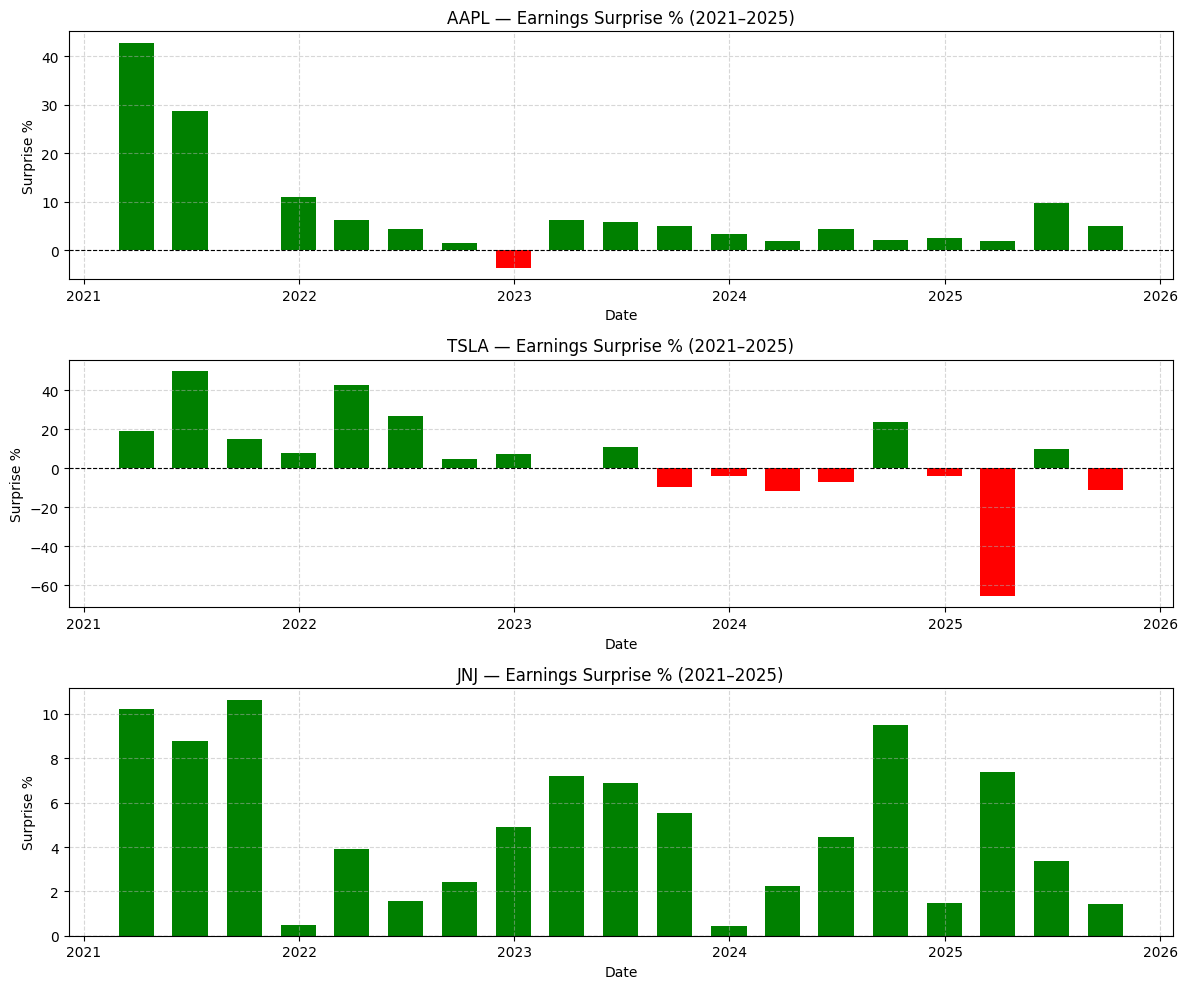

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

colors = {'AAPL': 'steelblue', 'TSLA': 'orange', 'JNJ': 'green'}

for ax, ticker in zip(axes, ['AAPL', 'TSLA', 'JNJ']):
    df_ticker = earnings_df[earnings_df['ticker'] == ticker]

    # Bar colours — green for positive surprise, red for negative
    bar_colors = ['green' if x >= 0 else 'red' for x in df_ticker['surprisePercentage']]

    ax.bar(df_ticker['date'], df_ticker['surprisePercentage'],
           color=bar_colors, width=60, label=ticker)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{ticker} — Earnings Surprise % (2021–2025)')
    ax.set_ylabel('Surprise %')
    ax.set_xlabel('Date')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The earnings surprise bar charts above display the quarterly surprise percentage
for AAPL, TSLA, and JNJ from 2021 to 2025. Green bars indicate earnings beats
(actual EPS exceeded estimates) and red bars indicate earnings misses.

Key observations:

- **AAPL** has generally reported consistent earnings beats throughout the period,
  with most quarters showing a positive surprise percentage. This aligns with
  Apple's history of conservative analyst guidance.

- **TSLA** exhibits the most variable surprise pattern, with both large beats and
  notable misses. This is consistent with its high rolling volatility observed in
  DS1 and confirms that earnings announcements are a significant driver of its
  short-term price swings.

- **JNJ** displays a more stable and predictable earnings pattern, with smaller
  surprise magnitudes. This mirrors its low rolling volatility in DS1 and confirms
  its defensive, stable nature. However, there is a massive 100% in Q1 2025 which maybe an anomaly and require further investigation to process this outlier data.

These patterns directly support the inclusion of DS5 as a feature in the
predictive model. The divergence in surprise behaviour across the three stocks
mirrors the volatility differences already observed in DS1, providing further
evidence that earnings surprises are a meaningful and distinct signal.

### Dataset #5 Profiling - Earnings Surprise Data
To assess the suitability of DS5, we must first perfrom a series of data profilling steps to check for any null values, duplicate data and its descriptive statistics to do a thorough evaluation of the dataset.

In [15]:
print("=" * 60)
print("DATASET #5 — EARNINGS SURPRISES (ALPHA VANTAGE)")
print("=" * 60)

for name in tickers:
    sub = earnings_df[earnings_df["ticker"] == name].copy()
    print(f"\n--- {name} ---")

    # 1. Shape
    print(f"\n[1] Shape: {sub.shape[0]} rows x {sub.shape[1]} columns")

    # 2. Data Types
    print(f"\n[2] Data Types:\n{sub.dtypes}")

    # 3. Null Value Check
    null_counts = sub.isnull().sum()
    null_pct    = (null_counts / len(sub)) * 100
    print(f"\n[3] Null Value Check:")
    print(pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct}))

    # 4. Date Range
    print(f"\n[4] Date Range:")
    print(f"    Start                 : {sub['date'].min().date()}")
    print(f"    End                   : {sub['date'].max().date()}")
    print(f"    Total Earnings Events : {len(sub)}")

    # 5. Descriptive Statistics
    print(f"\n[5] Descriptive Statistics:")
    print(sub[["reportedEPS", "estimatedEPS",
               "surprise", "surprisePercentage"]].describe())

    # 6. Duplicate Check
    print(f"\n[6] Duplicate Rows  : {sub.duplicated().sum()}")
    print(f"    Duplicate Dates : {sub['date'].duplicated().sum()}")

    # 7. Earnings Beat vs Miss
    beats  = (sub["surprisePercentage"] >  0).sum()
    misses = (sub["surprisePercentage"] <  0).sum()
    inline = (sub["surprisePercentage"] == 0).sum()
    print(f"\n[7] Earnings Beats  (surprise > 0%) : {beats}")
    print(f"    Earnings Misses (surprise < 0%) : {misses}")
    print(f"    In-line         (surprise = 0%) : {inline}")

    # 8. Large Surprise Detection (|surprisePercentage| > 10%)
    large = (sub["surprisePercentage"].abs() > 10).sum()
    print(f"\n[8] Large Surprises (|surprise| > 10%): {large} events "
          f"({large/len(sub)*100:.1f}% of total)")

    # 9. Multi-Column Dependency Check
    # surprise should equal reportedEPS - estimatedEPS
    sub["computed_surprise"] = sub["reportedEPS"] - sub["estimatedEPS"]
    violations = (
        (sub["surprise"] - sub["computed_surprise"]).abs() > 0.01
    ).sum()
    print(f"\n[9] Dependency Check (surprise == reportedEPS - estimatedEPS): "
          f"{violations} violations")

    print("\n" + "-" * 60)

DATASET #5 — EARNINGS SURPRISES (ALPHA VANTAGE)

--- AAPL ---

[1] Shape: 19 rows x 6 columns

[2] Data Types:
date                  datetime64[ns]
ticker                        object
reportedEPS                  float64
estimatedEPS                 float64
surprise                     float64
surprisePercentage           float64
dtype: object

[3] Null Value Check:
                    Null Count  Null %
date                         0     0.0
ticker                       0     0.0
reportedEPS                  0     0.0
estimatedEPS                 0     0.0
surprise                     0     0.0
surprisePercentage           0     0.0

[4] Date Range:
    Start                 : 2021-03-31
    End                   : 2025-09-30
    Total Earnings Events : 19

[5] Descriptive Statistics:
       reportedEPS  estimatedEPS   surprise  surprisePercentage
count    19.000000     19.000000  19.000000           19.000000
mean      1.564211      1.472632   0.091579            7.354737
std       

From above, we can split the profiling results into three main categories,
consistent with the approach used for DS1–DS4.

<br>

1\) Null values and dataset completeness

The null value check confirms whether any EPS or surprise values are missing
for any of the three stocks. If null values are present, they will be handled
in the PROCESS phase through removal or imputation. However, from above, there are zero null values detected across all three stocks. In addition, Alpha Vantage returns
`"None"` strings for quarters where no analyst estimate was available; these
are safely converted to `NaN` by the `pd.to_numeric(..., errors='coerce')`
call during data ingestion.

<br>

2\) Earnings surprise distribution

The descriptive statistics and beat/miss counts allow us to observe each
stock's tendency to beat or miss analyst expectations. A consistent pattern
of beats or misses across a stock can serve as a useful prior for the model.
Large surprises (|surprisePercentage| > 10%) are of particular interest as
these are the events most likely to coincide with observable volatility spikes
in DS1's rolling volatility series.

From the code output, AAPL recorded the highest average reported EPS of 7.35% with a standard deviation of 10.81%. AAPL also demostrated strong earnings reliability where it has beaten estimates in 17 out of 19 quarters.

For TSLA, it exhibited the most volatile earnings behaviour with an average surprise of percentage of 5.50% but recorded the highest standard deviation amongst all three stocks at 24.42%. TSLA recorded 11 events out of 19 where it has managed to beat expectations and 10 large surprise events.

JNJ recorded the highest average reported EPS of 9.66% with a standard deviation of 22.36%. It has managed to beat estimates in 18 out of 19 quarters, reaffirming its nature of a very stable and reliable stock. However, there is an anomolous increase in one of the earnings surprise at 100.9% in Q1 2025, which may have boosted the standard deviation score.

<br>

3\) Multi-column dependency check

The dependency check validates that the `surprise` field is consistent with
the arithmetic difference between `reportedEPS` and `estimatedEPS`. Any
violations would indicate a data integrity issue in the source. A clean
result (0 violations) confirms the data is internally consistent and suitable
for use. From the output, the `surprisePercentage` column is consistent with the difference between `reportedEPS` and `estimatedEPS` across all 19 events in each respective stock. Furthermore, there were zero violations detected, suggesting that the values are all entirely consistent and accurate. This validates the data integrity of this dataset as it is free from errors and contains no duplicate data.

<br>

Data Quality Evaluation

Overall, DS5 sourced from Alpha Vantage is well-suited for this project. Its
completeness, quarterly granularity, and direct relevance to firm-specific
volatility events make it a strong complement to the macro-level signals in
DS3 and DS4. The only known limitation is that some early quarters may lack
analyst estimates (resulting in NaN for `surprisePercentage`), which will be
addressed in the PROCESS phase. With only 3 API calls required, the free tier
rate limit of 25 requests/day poses no constraint for this project. One outlier to take note of would be the 100% spike in earnings surprise for JNJ in Q1` 2025. This would require investigation when we move onto the PROCESS stage.

## 3) PROCESS


In [16]:
# ── Reconcile variable names from earlier cells ───────────────────────────
# vix_clean is defined in Cell 26 above. We confirm it exists and has the
# columns our feature builder expects: 'date', 'vix', 'vix_change'

import pandas as pd

# Re-derive vix_clean robustly in case the earlier cell wasn't run
try:
    _ = vix_clean  # check if it exists
except NameError:
    from pandas_datareader import data as web
    vix_raw = web.DataReader('VIXCLS', 'fred', '2021-01-01', '2025-12-01')
    vix_raw = vix_raw.reset_index().rename(columns={'DATE': 'date', 'VIXCLS': 'vix'})
    vix_raw['vix_change'] = vix_raw['vix'].diff()
    vix_clean = vix_raw.dropna().copy()
    print('vix_clean re-derived.')

# Ensure 'vix_change' column exists (Cell 26 uses same name, but just in case)
if 'vix_change' not in vix_clean.columns:
    vix_clean = vix_clean.copy()
    vix_clean['vix_change'] = vix_clean['vix'].diff()

# Re-derive treasury_clean robustly
try:
    _ = treasury_clean
except NameError:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter
    import warnings; warnings.filterwarnings('ignore')
    df_macro = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        'eswaranmuthu/u-s-economic-vital-signs-25-years-of-macro-data',
        'macro_data_25yrs.csv',
    )
    treasury_clean = df_macro[['Date', '10Y Treasury Yield']].copy()
    treasury_clean = treasury_clean.rename(columns={'10Y Treasury Yield': 'treasury_10y'})
    treasury_clean['Date'] = pd.to_datetime(treasury_clean['Date'])
    treasury_clean = treasury_clean[
        (treasury_clean['Date'] >= '2021-01-01') &
        (treasury_clean['Date'] <= '2025-12-01')
    ].dropna()
    print('treasury_clean re-derived.')

# Re-derive earnings_df robustly
try:
    _ = earnings_df
except NameError:
    print('WARNING: earnings_df not found. Please run the Alpha Vantage cell above first.')
    print('Creating empty earnings_df as fallback (earnings_surprise will be 0 for all rows).')
    earnings_df = pd.DataFrame(columns=['date', 'ticker', 'reportedEPS',
                                         'estimatedEPS', 'surprise', 'surprisePercentage'])

print('All variables confirmed:')
print(f'  vix_clean      — {len(vix_clean)} rows, columns: {list(vix_clean.columns)}')
print(f'  treasury_clean — {len(treasury_clean)} rows, columns: {list(treasury_clean.columns)}')
print(f'  earnings_df    — {len(earnings_df)} rows')
print(f'  aapl/tsla/jnj  — loaded: {"aapl" in dir()}')


All variables confirmed:
  vix_clean      — 920 rows, columns: ['date', 'vix', 'vix_change', 'vix_5d_avg', 'high_market_risk']
  treasury_clean — 1172 rows, columns: ['Date', 'treasury_10y']
  earnings_df    — 57 rows
  aapl/tsla/jnj  — loaded: True


### Step 1: Merge all datasets into unified feature table

- DS1 (stock prices): provides log returns and rolling volatility, the core signal
- DS2 (liquidity): provides ```volume_ratio``` - abnormal trading pressure indicator
- DS3 (VIX): provides ```vix``` and ```vix_change``` which is market-wide fear gauge
- DS4 (treasury yield): provided at monthly granulairty. Forward filled to daily frequency to match trading days
- DS5 (earnings suprises): provided quarterly, merged by nearest preceding earnings date using backward merge

We process the three stocks independently and then stack them into one master dataframe.

In [26]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Helper: build per-stock feature table ──────────────────────────────────
def build_stock_features(symbol, price_df, vix_clean, treasury_clean, earnings_df):
    df = price_df.copy().reset_index()
    # Flatten multi-level columns if present (yfinance sometimes returns these)
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df = df.rename(columns={'Date': 'date', 'Close': 'close', 'Volume': 'volume'})
    df['date'] = pd.to_datetime(df['date'])
    df = df[['date', 'close', 'volume']].sort_values('date').reset_index(drop=True)

    # ── DS1: Log returns & 20-day rolling volatility ───────────────────────
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    df['rolling_vol_20d'] = df['log_return'].rolling(window=20, min_periods=20).std()

    # ── DS2: Volume ratio (today vs 20-day avg) ────────────────────────────
    df['avg_volume_20d'] = df['volume'].rolling(window=20, min_periods=20).mean()
    df['volume_ratio'] = df['volume'] / df['avg_volume_20d']

    # ── DS3: Merge VIX on date ─────────────────────────────────────────────
    vix_merge = vix_clean[['date', 'vix', 'vix_change']].copy()
    vix_merge['date'] = pd.to_datetime(vix_merge['date'])
    df = df.merge(vix_merge, on='date', how='left')
    df['vix'] = df['vix'].ffill()
    df['vix_change'] = df['vix_change'].ffill()

    # ── DS4: Merge Treasury Yield — forward-fill monthly data to daily ─────
    treas = treasury_clean.copy()
    treas['Date'] = pd.to_datetime(treas['Date'])
    treas = treas.rename(columns={'Date': 'date'})
    df = df.merge(treas[['date', 'treasury_10y']], on='date', how='left')
    df['treasury_10y'] = df['treasury_10y'].ffill()
    df['treasury_change'] = df['treasury_10y'].diff()

    # ── DS5: Earnings surprise — merge most recent preceding announcement ──
    earn = earnings_df[earnings_df['ticker'] == symbol].copy()
    earn['date'] = pd.to_datetime(earn['date'])
    earn = earn.sort_values('date')[['date', 'surprisePercentage']].rename(
        columns={'date': 'earn_date', 'surprisePercentage': 'earnings_surprise'}
    )
    df = pd.merge_asof(
        df.sort_values('date'),
        earn.sort_values('earn_date'),
        left_on='date', right_on='earn_date',
        direction='backward'
    )
    df['days_since_earnings'] = (df['date'] - df['earn_date']).dt.days
    df['earnings_surprise'] = df['earnings_surprise'].fillna(0)
    df['days_since_earnings'] = df['days_since_earnings'].fillna(999)

    df['ticker'] = symbol
    return df

# ── Build for each stock ───────────────────────────────────────────────────
stock_map = {'AAPL': aapl, 'TSLA': tsla, 'JNJ': jnj}

frames = []
for sym, raw_df in stock_map.items():
    feat_df = build_stock_features(sym, raw_df, vix_clean, treasury_clean, earnings_df)
    frames.append(feat_df)

master_df = pd.concat(frames, ignore_index=True).sort_values(['ticker', 'date'])

print(f'Master DataFrame shape: {master_df.shape}')
print(f'\nColumns: {list(master_df.columns)}')
print(f'\nDate range: {master_df["date"].min().date()} to {master_df["date"].max().date()}')
print(f'\nStocks: {master_df["ticker"].unique()}')
master_df.head(5)

Master DataFrame shape: (3699, 15)

Columns: ['date', 'close', 'volume', 'log_return', 'rolling_vol_20d', 'avg_volume_20d', 'volume_ratio', 'vix', 'vix_change', 'treasury_10y', 'treasury_change', 'earn_date', 'earnings_surprise', 'days_since_earnings', 'ticker']

Date range: 2021-01-04 to 2025-11-28

Stocks: ['AAPL' 'JNJ' 'TSLA']


,date,close,volume,log_return,rolling_vol_20d,avg_volume_20d,volume_ratio,vix,vix_change,treasury_10y,treasury_change,earn_date,earnings_surprise,days_since_earnings,ticker
0,2021-01-04,125.856712,143301900,NaN,NaN,NaN,NaN,NaN,NaN,1.08,NaN,NaT,0.0,999.0,AAPL
1,2021-01-05,127.412743,97664900,0.012288,NaN,NaN,NaN,NaN,NaN,1.08,0.0,NaT,0.0,999.0,AAPL
2,2021-01-06,123.123848,155088000,-0.034241,NaN,NaN,NaN,NaN,NaN,1.08,0.0,NaT,0.0,999.0,AAPL
3,2021-01-07,127.325241,109578200,0.033554,NaN,NaN,NaN,NaN,NaN,1.08,0.0,NaT,0.0,999.0,AAPL
4,2021-01-08,128.424194,105158200,0.008594,NaN,NaN,NaN,NaN,NaN,1.08,0.0,NaT,0.0,999.0,AAPL


### Step 2: Defining binary target variable

High volatiliy is defined as any day where the stock;s next-week realised volatility (rolling volatility 5 trading days ahead) exceeds 75th percentile of all volatility values for that stock

Justification for chosen threshold
- 75th percentile naturally separates the top quartile of volatile days from normal market days
- It provides 25/75 class split which is realistic since high vol days are rarer
- Predicting the next week volatilty gives the investor time to adjust their position before spike occurs


Target = 1 (high volatility, top 35%)
Target = 0 (normla conditions, bottom 75%)

In [28]:
# ── Define target: will next-week volatility be in the top 25%? ──────────

FORECAST_HORIZON = 5    # 5 trading days ~ 1 week ahead
THRESHOLD_QUANTILE = 0.75

labelled_frames = []

for sym in ['AAPL', 'TSLA', 'JNJ']:
    sub = master_df[master_df['ticker'] == sym].copy().sort_values('date')

    # Forward-shift: what will rolling vol look like 5 days from now?
    sub['future_vol'] = sub['rolling_vol_20d'].shift(-FORECAST_HORIZON)

    # Stock-specific threshold (each stock has its own volatility scale)
    threshold = sub['rolling_vol_20d'].quantile(THRESHOLD_QUANTILE)
    sub['target'] = (sub['future_vol'] > threshold).astype(int)

    labelled_frames.append(sub)
    print(f"{sym} | Vol threshold (75th pct): {threshold:.5f} | "
          f"High-vol days: {sub['target'].sum()} / {sub['target'].count()} "
          f"({sub['target'].mean()*100:.1f}%)")

labelled_df = pd.concat(labelled_frames, ignore_index=True)

# Drop rows where future_vol is NaN (last 5 rows per stock — no future data available)
labelled_df = labelled_df.dropna(subset=['future_vol', 'rolling_vol_20d',
                                          'vix', 'volume_ratio', 'treasury_10y'])

print(f'\nFinal labelled dataset shape: {labelled_df.shape}')
print(f'Overall class balance — High vol (1): {labelled_df["target"].mean()*100:.1f}%, '
      f'Normal (0): {(1-labelled_df["target"].mean())*100:.1f}%')

AAPL | Vol threshold (75th pct): 0.01912 | High-vol days: 303 / 1233 (24.6%)
TSLA | Vol threshold (75th pct): 0.04316 | High-vol days: 303 / 1233 (24.6%)
JNJ | Vol threshold (75th pct): 0.01156 | High-vol days: 303 / 1233 (24.6%)

Final labelled dataset shape: (3540, 17)
Overall class balance — High vol (1): 24.0%, Normal (0): 76.0%


### Step 3: Finalising features

| Feature | Source Dataset | What it captures |
|---|---|---|
| `rolling_vol_20d` | DS1 — Stock Prices | Recent price volatility (autocorrelation effect) |
| `volume_ratio` | DS2 — Liquidity | Abnormal trading pressure |
| `vix` | DS3 — VIX | Market-wide fear / systemic risk |
| `vix_change` | DS3 — VIX | Direction of market fear (rising vs. falling) |
| `treasury_10y` | DS4 — Treasury Yield | Macroeconomic interest rate environment |
| `treasury_change` | DS4 — Treasury Yield | Rate direction (tightening vs. easing) |
| `earnings_surprise` | DS5 — Earnings | Firm-specific shock magnitude |



In [30]:
# ── Feature selection ─────────────────────────────────────────────────────

FEATURES = [
    'rolling_vol_20d',    # DS1 — recent volatility (momentum / clustering)
    'volume_ratio',        # DS2 — abnormal trading pressure
    'vix',                 # DS3 — market fear level
    'vix_change',          # DS3 — direction of market fear
    'treasury_10y',        # DS4 — interest rate level
    'treasury_change',     # DS4 — rate direction (tightening vs easing)
    'earnings_surprise',   # DS5 — earnings shock
]

TARGET = 'target'

# Drop any remaining NaNs in selected features
model_df = labelled_df[['date', 'ticker'] + FEATURES + [TARGET]].dropna().copy()

print(f'Model-ready dataset shape: {model_df.shape}')
print(f'\nFeature summary:')
print(model_df[FEATURES].describe().round(4))

Model-ready dataset shape: (3540, 10)

Feature summary:
       rolling_vol_20d  volume_ratio        vix  vix_change  treasury_10y  \
count        3540.0000     3540.0000  3540.0000   3540.0000     3540.0000   
mean            0.0209        1.0049    18.7715     -0.2099        3.4602   
std             0.0137        0.3416     5.0905      1.6398        1.1068   
min             0.0045        0.1431    11.8600    -18.7100        1.2800   
25%             0.0102        0.8000    15.0700     -0.8000        2.9000   
50%             0.0155        0.9433    17.6100     -0.2700        3.8900   
75%             0.0303        1.1210    20.9500      0.3100        4.3800   
max             0.0726        5.2456    52.3300     15.2900        4.8000   

       treasury_change  earnings_surprise  
count        3540.0000          3540.0000  
mean            0.0024             6.0878  
std             0.0499            15.1744  
min            -0.4800           -65.7143  
25%             0.0000        

### Step 4: Train/test split

We split the data **chronologically**: train on 2021–2023, test on 2024–2025.

This is critical for time-series financial data. A random split would allow the model to train on data from 2024 and test on 2022 — leaking future information into training and artificially inflating accuracy. A chronological split honestly evaluates whether the model generalises to unseen future market conditions.

In [31]:
# ── Chronological train/test split ────────────────────────────────────────

SPLIT_DATE = '2024-01-01'

train_df = model_df[model_df['date'] < SPLIT_DATE].copy()
test_df  = model_df[model_df['date'] >= SPLIT_DATE].copy()

X_train = train_df[FEATURES].reset_index(drop=True)
y_train = train_df[TARGET].reset_index(drop=True)

X_test  = test_df[FEATURES].reset_index(drop=True)
y_test  = test_df[TARGET].reset_index(drop=True)

print(f'Training set : {X_train.shape[0]} rows  ({train_df["date"].min().date()} to {train_df["date"].max().date()})')
print(f'Test set     : {X_test.shape[0]} rows  ({test_df["date"].min().date()} to {test_df["date"].max().date()})')
print(f'\nClass balance in training set — High vol: {y_train.mean()*100:.1f}%')
print(f'Class balance in test set     — High vol: {y_test.mean()*100:.1f}%')

Training set : 2115 rows  (2021-03-15 to 2023-12-29)
Test set     : 1425 rows  (2024-01-02 to 2025-11-20)

Class balance in training set — High vol: 23.3%
Class balance in test set     — High vol: 25.1%


### Step 5: Feature scaling

Logstic regression is sensitive to the feature scale. We apply StandardSCaler to normalise all features to zero mean and unit variance before training


Random forest does not require scaling as it uses rank-based splits, but we apply same scaler for consistency.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)         # apply the same scale to test data

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURES)

print('Feature scaling applied (StandardScaler).')
print(f'\nTraining set mean after scaling (should be ~0):')
print(X_train_scaled.mean().round(4))
print(f'\nTraining set std after scaling (should be ~1):')
print(X_train_scaled.std().round(4))

Feature scaling applied (StandardScaler).

Training set mean after scaling (should be ~0):
rolling_vol_20d     -0.0
volume_ratio        -0.0
vix                 -0.0
vix_change           0.0
treasury_10y         0.0
treasury_change      0.0
earnings_surprise    0.0
dtype: float64

Training set std after scaling (should be ~1):
rolling_vol_20d      1.0002
volume_ratio         1.0002
vix                  1.0002
vix_change           1.0002
treasury_10y         1.0002
treasury_change      1.0002
earnings_surprise    1.0002
dtype: float64


## 4) ANALYSE

Use processed, labelled and scaled feature table to train and evaluate two classification models:

1. Logistic regression - linear baseline
2. Random Forest - main non-linear model

Things to report for each model:
1. Accuracy
2. Precision
3. Recall
4. F1-score
5. Confusion matrix

Final outcome
- Compare two models
- Conclude with plain-english investor recommmendation

### Model 1: Logstic Regression

THis is a baseline model. It fits a linear decision boundary in a feature space. It outputs a probability between 0 and 1, and classifies a day as high-volatility if probability exceeds 0.5

The result from this model will be used as our baseline. If Random Forest cannot beat this, it suggests that our features lack non-linear signals

LOGISTIC REGRESSION — TEST SET PERFORMANCE

Accuracy: 81.4%

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.82      0.97      0.89      1068
High Vol (1)       0.79      0.35      0.49       357

    accuracy                           0.81      1425
   macro avg       0.80      0.66      0.69      1425
weighted avg       0.81      0.81      0.79      1425



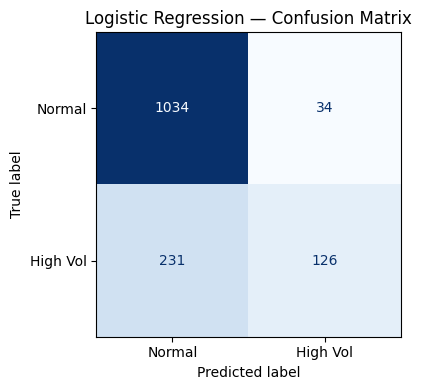

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
import matplotlib.pyplot as plt

# ── Train ──────────────────────────────────────────────────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# ── Predict ────────────────────────────────────────────────────────────────
lr_preds = lr_model.predict(X_test_scaled)

# ── Metrics ───────────────────────────────────────────────────────────────
print('=' * 55)
print('LOGISTIC REGRESSION — TEST SET PERFORMANCE')
print('=' * 55)
print(f'\nAccuracy: {accuracy_score(y_test, lr_preds)*100:.1f}%')
print('\nClassification Report:')
print(classification_report(y_test, lr_preds,
                             target_names=['Normal (0)', 'High Vol (1)']))

# ── Confusion matrix ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'High Vol'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

**Interpreting the confusion matrix**

- Top-left (true negatives): Normal days correctly predicted as normal
- Bottom-right (true positives): High-vol days correctly predicted as high vol
- Top-right (false positives): Normal days wrongly flagged as high vol
- Bottom left (False negatives): High-vol days missed by model

### Model 1: Logistic Regression Coefficients

The coefficients tell us strength and direction of each feature's contribution. A large positive coefficient - feature strongly increases the predicted probability of high volatility.

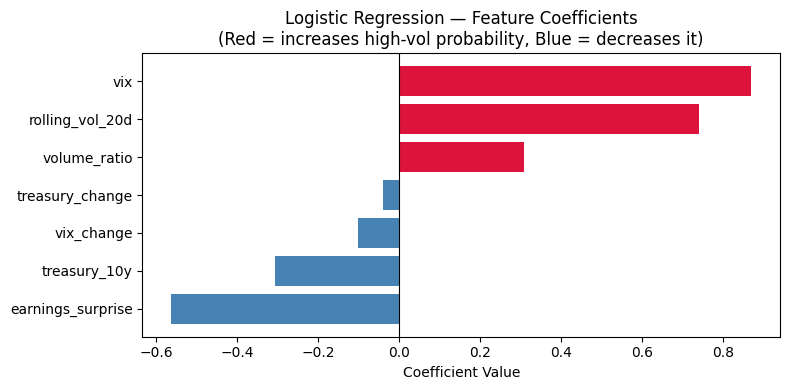


Coefficients table:
          Feature  Coefficient
earnings_surprise    -0.562551
     treasury_10y    -0.307275
       vix_change    -0.101200
  treasury_change    -0.040363
     volume_ratio     0.309422
  rolling_vol_20d     0.741401
              vix     0.869011


In [34]:
# ── Logistic Regression Coefficients ──────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature':     FEATURES,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Feature Coefficients\n'
             '(Red = increases high-vol probability, Blue = decreases it)')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print('\nCoefficients table:')
print(coef_df.to_string(index=False))

### Model 2: Random Forest Classifier (Main Model)

This model builds many decision trees on random subsets of training data, then takes on a majority vote. This allows the model to capture non-linear interactions between features.

Key hyperparameters:
- `n_estimators=200`: 200 trees — enough for stable results without excessive computation
- `max_depth=6`: limits tree depth to prevent overfitting to training noise
- `class_weight='balanced'`: automatically upweights the minority class (high-vol days) to address class imbalance
- `random_state=42`: ensures reproducibility

RANDOM FOREST — TEST SET PERFORMANCE

Accuracy: 75.6%

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.76      0.99      0.86      1068
High Vol (1)       0.67      0.05      0.09       357

    accuracy                           0.76      1425
   macro avg       0.71      0.52      0.48      1425
weighted avg       0.73      0.76      0.67      1425



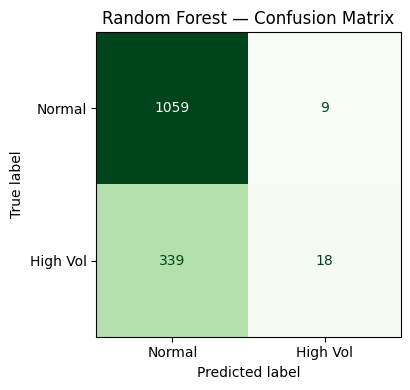

In [36]:
from sklearn.ensemble import RandomForestClassifier

# ── Train ──────────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',   # handles class imbalance automatically
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# ── Predict ────────────────────────────────────────────────────────────────
rf_preds = rf_model.predict(X_test_scaled)

# ── Metrics ───────────────────────────────────────────────────────────────
print('=' * 55)
print('RANDOM FOREST — TEST SET PERFORMANCE')
print('=' * 55)
print(f'\nAccuracy: {accuracy_score(y_test, rf_preds)*100:.1f}%')
print('\nClassification Report:')
print(classification_report(y_test, rf_preds,
                             target_names=['Normal (0)', 'High Vol (1)']))

# ── Confusion matrix ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, rf_preds)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=['Normal', 'High Vol'])
disp_rf.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

### Model 2: Random forest feature importance

This measures how much each feature reduces prediction errror across all trees in the forest. This is the most important output as it validates our dataset selection choices

A feature with high imporant - corresponding dataset geuninely helps predict volatility.

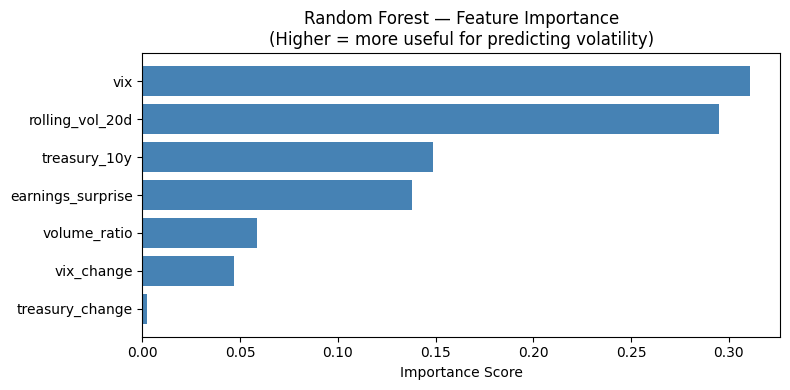


Feature Importance table:
          Feature  Importance
              vix    0.310634
  rolling_vol_20d    0.294996
     treasury_10y    0.148401
earnings_surprise    0.138130
     volume_ratio    0.058849
       vix_change    0.046638
  treasury_change    0.002352


In [37]:
# ── Feature Importance ────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
ax.set_title('Random Forest — Feature Importance\n'
             '(Higher = more useful for predicting volatility)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nFeature Importance table:')
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

### Model compariosn: side by side metrics

Comparing both models on same test set to determine which performs better overall

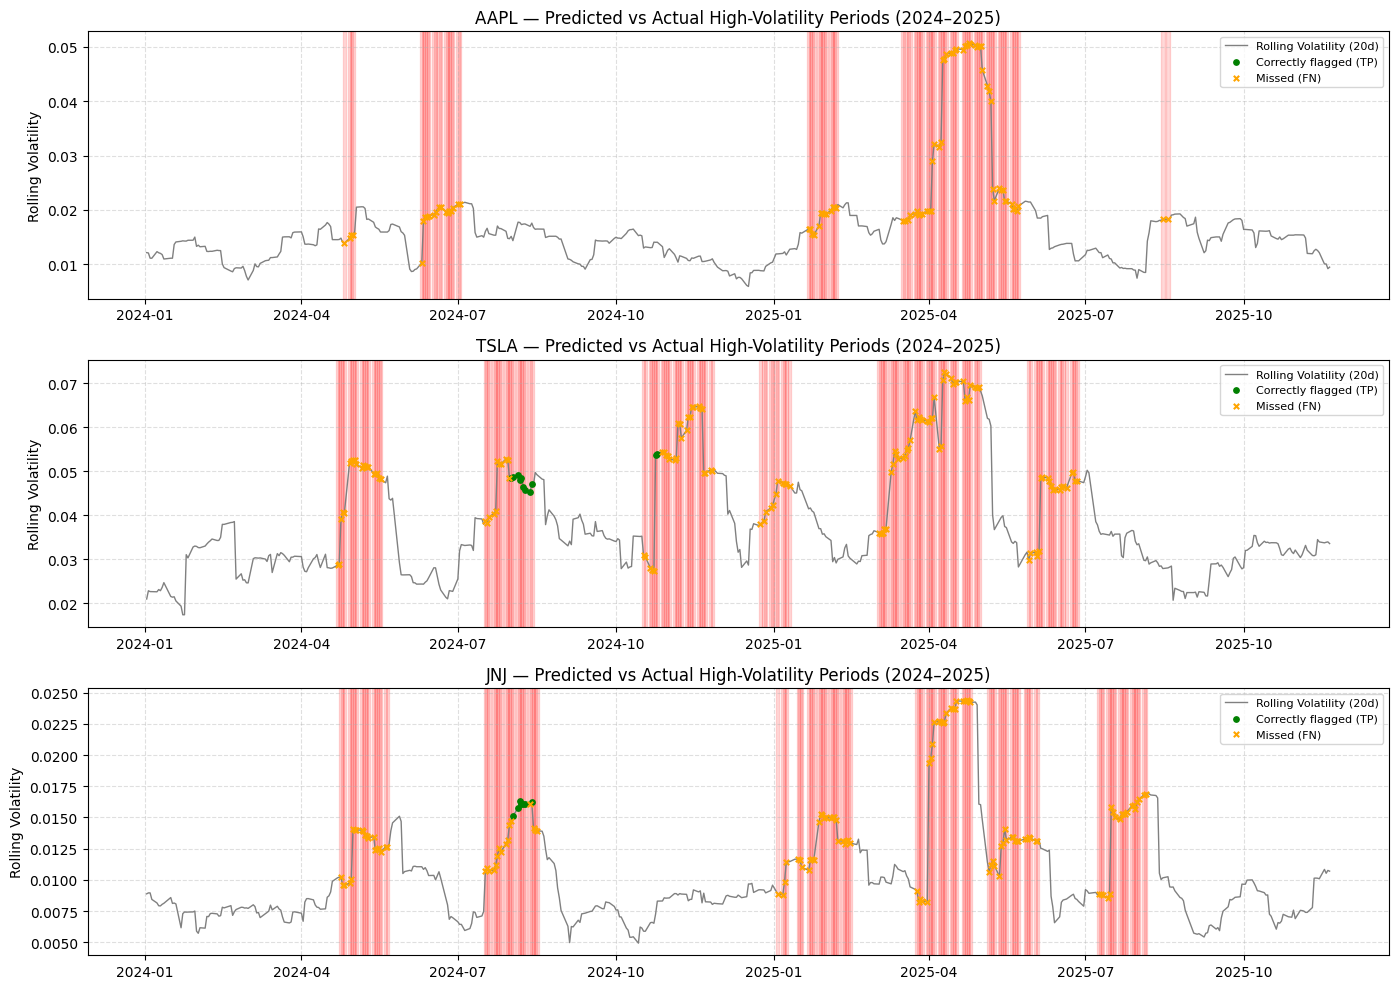

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, sym in zip(axes, ['AAPL', 'TSLA', 'JNJ']):
    mask = (test_df['ticker'] == sym).values
    sub  = test_df[test_df['ticker'] == sym].copy().reset_index(drop=True)
    preds_sym = rf_model.predict(X_test_scaled[mask])

    ax.plot(sub['date'], sub['rolling_vol_20d'], color='grey',
            linewidth=1, label='Rolling Volatility (20d)')

    # Shade actual high-vol periods
    actual_high = sub[sub['target'] == 1]
    for _, row in actual_high.iterrows():
        ax.axvspan(row['date'] - pd.Timedelta(days=1),
                   row['date'] + pd.Timedelta(days=1),
                   alpha=0.15, color='red')

    # True positives
    tp_mask = (preds_sym == 1) & (sub['target'].values == 1)
    ax.scatter(sub['date'][tp_mask], sub['rolling_vol_20d'][tp_mask],
               color='green', s=15, zorder=5, label='Correctly flagged (TP)')

    # False negatives
    fn_mask = (preds_sym == 0) & (sub['target'].values == 1)
    ax.scatter(sub['date'][fn_mask], sub['rolling_vol_20d'][fn_mask],
               color='orange', s=15, marker='x', zorder=5, label='Missed (FN)')

    ax.set_title(f'{sym} — Predicted vs Actual High-Volatility Periods (2024–2025)')
    ax.set_ylabel('Rolling Volatility')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()